# TA-XLM-R v4 — Optimized for >0.75 Macro-F1
## Transliteration-Aware XLM-RoBERTa for Banglish Sentiment Analysis

**Dataset:** Banglish-only (Latin-script Bangla) — columns: `ID`, `Banglish_Text`, `Label`

**Key Improvements over v3:**
- **Mean-pooling over all tokens** (not just CLS) — captures richer sequence context
- **Char CNN** replaces BiLSTM — faster, better local n-gram features
- **Larger char hidden dim** (256 → 384) — better representational capacity
- **Unfreeze top 6 layers** (was top 4) — more XLM-R fine-tuning
- **Separate LR groups**: embeddings frozen, lower layers 1e-5, upper layers 2e-5, head 1e-4
- **Gradient accumulation** (steps=4) → effective batch 64 without OOM
- **Mixup augmentation** on embeddings — improves generalization
- **Label smoothing via CrossEntropy** (cleaner than combined with Focal)
- **Longer max_len=160** — captures more context
- **Warmup 15%** of steps (was 10%)
- **SWA (Stochastic Weight Averaging)** — smooths loss landscape
- **Expanded transliteration map** — better normalization coverage


## 1. Install & Import

In [1]:
import subprocess, sys
import torch
print(f'Current torch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

!pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118 -q
!pip install transformers==4.40.0 scikit-learn pandas numpy matplotlib seaborn -q
print('\nInstallation complete. RESTART KERNEL if first run, then re-run from cell 2.')

Current torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.

Installation complet

In [2]:
import os, re, json, random, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

matplotlib.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── CUDA Safety ──────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    try:
        _t = torch.zeros(2, 2).cuda()
        _t2 = torch.nn.LSTM(2, 2).cuda()
        del _t, _t2
        DEVICE = torch.device('cuda')
        print(f'CUDA OK — GPU: {torch.cuda.get_device_name(0)}')
    except Exception as e:
        print(f'CUDA test failed: {e}. Falling back to CPU.')
        DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cpu')
    print('CUDA not available — using CPU.')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

# ── Config ───────────────────────────────────────────────────────────────────
CFG = {
    'xlmr_model'     : 'xlm-roberta-base',
    'max_len'        : 160,          # ↑ from 128 — more context captured
    'batch_size'     : 16,
    'grad_accum'     : 4,            # NEW: effective batch = 64
    'lr_embed'       : 0.0,          # frozen
    'lr_lower'       : 1e-5,         # NEW: layers 0-5 — very slow
    'lr_upper'       : 2e-5,         # layers 6-11 — moderate
    'lr_head'        : 1e-4,         # NEW: classifier head — fast
    'epochs'         : 20,
    'patience'       : 6,            # ↑ from 5
    'dropout'        : 0.2,          # ↓ from 0.3 — less regularization needed
    'char_emb_dim'   : 64,
    'char_out_dim'   : 384,          # ↑ from 256
    'num_heads'      : 8,            # ↑ from 4
    'num_classes'    : 4,
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,          # NEW: mixup augmentation
    'warmup_ratio'   : 0.15,         # ↑ from 0.10
    'test_size'      : 0.15,
    'val_size'       : 0.15,
    'seeds'          : [42, 123, 7],
    'swa_start_frac' : 0.75,         # NEW: SWA starts at 75% of training
    'swa_lr'         : 5e-6,         # NEW: SWA learning rate
    'unfreeze_from_layer': 6,        # ↑ from 8 — fine-tune more layers
}

LABEL2ID = {
    'Literary Appreciation': 0,
    'Analytical Reflection': 1,
    'Constructive Critique': 2,
    'Strong Critique'      : 3,
}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
SHORT_LBL = ['Lit. App.', 'Anal. Ref.', 'Cons. Crit.', 'Str. Crit.']
print('Configuration ready.')

CUDA OK — GPU: Tesla T4
Device: cuda | PyTorch: 2.10.0+cu128
Configuration ready.


## 2. Load Dataset

In [3]:
dataset_path = "/kaggle/input/datasets/rafsanhasanpronoy/banglish-book-review/BBBRC old Dataset_Banglish.csv"
print(f'Using: {dataset_path}')

Using: /kaggle/input/datasets/rafsanhasanpronoy/banglish-book-review/BBBRC old Dataset_Banglish.csv


In [4]:
df_raw = pd.read_csv(dataset_path)
print(f'Original shape: {df_raw.shape}')
print(f'Original columns: {df_raw.columns.tolist()}')

# Shuffle and reset ID
df_raw = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)
df_raw['ID'] = df_raw.index + 1
# Reorder columns: ID, Banglish_Text, Label
df_raw = df_raw[['ID', 'Banglish_Text', 'Label']]

print('\nAfter shuffling and ID reset:')
print(df_raw.head())


Original shape: (12659, 3)
Original columns: ['ID', 'Banglish_Text', 'Label']

After shuffling and ID reset:
   ID                                      Banglish_Text  \
0   1                                Bahari boi kajer na   
1   2  Jibon bodle dewar jonno jothheshto....#_Amar E...   
2   3  shahityik, shangbadik ebong rajnoitik hishebe ...   
3   4  Boier kono bornona nai. Ar boiyer title hocche...   
4   5  Hashi-kanna, bhanga-gora, utthan-poton niyei a...   

                   Label  
0        Strong Critique  
1  Literary Appreciation  
2  Analytical Reflection  
3  Constructive Critique  
4  Analytical Reflection  


In [5]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

# Column names are now fixed
text_col  = 'Banglish_Text'
label_col = 'Label'

df['text']  = df[text_col].astype(str).str.strip()
df['label'] = df[label_col].str.strip().map(LABEL2ID)
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

def detect_script(text):
    bangla_chars = len(re.findall(r'[\u0980-\u09FF]', text))
    latin_chars  = len(re.findall(r'[a-zA-Z]', text))
    if bangla_chars > latin_chars: return 'Bangla'
    elif latin_chars > bangla_chars: return 'Banglish'
    return 'Mixed'

df['script'] = df['text'].apply(detect_script)

# ── Keep ONLY Banglish rows ──────────────────────────────────────────────────
df = df[df['script'] == 'Banglish'].reset_index(drop=True)
print(f'Banglish-only rows: {len(df)}')
print('Label dist:', df['label'].value_counts().to_dict())
print('Script dist:', df['script'].value_counts().to_dict())


Banglish-only rows: 12619
Label dist: {0: 8973, 1: 2429, 2: 806, 3: 411}
Script dist: {'Banglish': 12619}


## 3. Expanded Transliteration Normalization

In [6]:
# ── Expanded transliteration map (v4: +20 new entries) ───────────────────────
TRANSLITERATION_MAP = {
    # 'good' variants
    r'\bvalo\b'        : 'bhalo',
    r'\bbhaalo\b'      : 'bhalo',
    r'\bvhalo\b'       : 'bhalo',
    r'\bvhala\b'       : 'bhala',
    r'\bvala\b'        : 'bhala',
    r'\bbhallow\b'     : 'bhalo',    # NEW
    r'\bbhalo\b'       : 'bhalo',
    # 'very' variants
    r'\bkub\b'         : 'khub',
    r'\bkhoob\b'       : 'khub',
    r'\bkhob\b'        : 'khub',
    r'\bkhub\b'        : 'khub',
    r'\bkhubi\b'       : 'khubi',    # NEW
    # sentiment
    r'\bbajey\b'       : 'baje',
    r'\bbaajey\b'      : 'baje',
    r'\boshadharan\b'  : 'oshadharon',
    r'\boshaadharon\b' : 'oshadharon',
    r'\bosadharon\b'   : 'oshadharon',   # NEW
    r'\bosadharan\b'   : 'oshadharon',   # NEW
    r'\bdarun\b'       : 'darun',        # NEW
    r'\bdaaroon\b'     : 'darun',        # NEW
    r'\bdharoon\b'     : 'darun',        # NEW
    r'\bharidam\b'     : 'haridam',      # NEW: 'terrible'
    r'\bmojar\b'       : 'mojar',        # NEW: 'fun'
    r'\bmojar\b'       : 'mojar',
    r'\bmojaar\b'      : 'mojar',        # NEW
    r'\bshundhor\b'    : 'shundor',
    r'\bsundor\b'      : 'shundor',
    r'\bsundhor\b'     : 'shundor',      # NEW
    # verbs
    r'\blageche\b'     : 'lagche',
    r'\blagechhe\b'    : 'lagche',
    r'\bhoyechhe\b'    : 'hoyeche',
    r'\bkorchhi\b'     : 'korchi',
    r'\bkorchhe\b'     : 'korche',       # NEW
    r'\bdekhechhi\b'   : 'dekhechi',     # NEW
    r'\bporechi\b'     : 'porechi',
    r'\bporechhi\b'    : 'porechi',
    r'\bparhchi\b'     : 'porchi',       # NEW: 'reading'
    r'\bparchhi\b'     : 'porchi',       # NEW
    # misc
    r'\bkharaap\b'     : 'kharap',
    r'\bkinto\b'       : 'kintu',
    r'\bvoyanok\b'     : 'bhayanok',
    r'\bvoalo\b'       : 'bhalo',
    r'\bbekar\b'       : 'bekar',        # already normalized
    r'\bbekaar\b'      : 'bekar',        # NEW
    r'\bnirashajonok\b': 'nirashajanak', # NEW: 'disappointing'
    r'\bniraasha\b'    : 'nirasha',      # NEW
    r'\bokkhom\b'      : 'okkham',       # NEW: 'incapable'
    r'\bprosongshanio\b': 'prasangshaniyo', # NEW: 'praiseworthy'
    r'\bprosongsha\b'  : 'prasangsha',   # NEW
    r'\banuvab\b'      : 'anubhav',      # NEW: 'experience'
    r'\bonubhob\b'     : 'anubhav',      # NEW
    r'\bonuvob\b'      : 'anubhav',      # NEW
}

def normalize_transliteration(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    # Keep Bangla Unicode + basic punctuation
    text = re.sub(r'[^\w\s\u0980-\u09FF!?.,।]', ' ', text)
    for pattern, replacement in TRANSLITERATION_MAP.items():
        text = re.sub(pattern, replacement, text)
    return text.strip()

df['text_norm'] = df['text'].apply(normalize_transliteration)
print(f'Normalization complete. Sample:')
print(df[['text', 'text_norm']].head(3))

Normalization complete. Sample:
                                                text  \
0                                Bahari boi kajer na   
1  Jibon bodle dewar jonno jothheshto....#_Amar E...   
2  shahityik, shangbadik ebong rajnoitik hishebe ...   

                                           text_norm  
0                                bahari boi kajer na  
1  jibon bodle dewar jonno jothheshto.... _amar e...  
2  shahityik, shangbadik ebong rajnoitik hishebe ...  


## 4. Character Vocabulary

In [7]:
def build_char_vocab(texts, max_chars=400):    # ↑ from 350
    counter = Counter(ch for t in texts for ch in t)
    vocab   = {'<PAD>': 0, '<UNK>': 1}
    for ch, _ in counter.most_common(max_chars):
        vocab[ch] = len(vocab)
    return vocab

def text_to_char_ids(text, vocab, max_len=160):
    ids = [vocab.get(ch, vocab['<UNK>']) for ch in text[:max_len]]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

CHAR_VOCAB = build_char_vocab(df['text_norm'].tolist())
print(f'Char vocab size: {len(CHAR_VOCAB)}')

Char vocab size: 113


## 5. Dataset & DataLoader

In [8]:
TOKENIZER = AutoTokenizer.from_pretrained(CFG['xlmr_model'])

class BanglaDataset(Dataset):
    def __init__(self, dataframe, tokenizer, char_vocab, max_len):
        self.texts      = dataframe['text_norm'].tolist()
        self.labels     = dataframe['label'].tolist()
        self.tokenizer  = tokenizer
        self.char_vocab = char_vocab
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]
        enc   = self.tokenizer(
            text, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        char_ids = torch.tensor(
            text_to_char_ids(text, self.char_vocab, self.max_len),
            dtype=torch.long
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'char_ids'       : char_ids,
            'label'          : torch.tensor(label, dtype=torch.long),
        }

def make_loader(df_split, shuffle=False):
    ds = BanglaDataset(df_split, TOKENIZER, CHAR_VOCAB, CFG['max_len'])
    return DataLoader(ds, batch_size=CFG['batch_size'],
                      shuffle=shuffle, num_workers=0, pin_memory=True)

print('Dataset class ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class ready.


## 6. TA-XLM-R v4 Architecture
### Key improvements: Char CNN, Mean-pooling, Larger fusion, Better LR groups

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  Character CNN Encoder (replaces BiLSTM — better local n-gram features)
# ─────────────────────────────────────────────────────────────────────────────
class CharCNNEncoder(nn.Module):
    """
    Multi-scale char CNN: captures 2,3,4-gram character patterns.
    Output dim = out_dim (via projection).
    """
    def __init__(self, vocab_size, emb_dim, out_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        # Three parallel convolutions with different kernel sizes
        num_filters = out_dim // 3
        self.conv2 = nn.Conv1d(emb_dim, num_filters, kernel_size=2, padding=1)
        self.conv3 = nn.Conv1d(emb_dim, num_filters, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(emb_dim, num_filters, kernel_size=4, padding=2)
        cnn_out = num_filters * 3
        self.proj = nn.Linear(cnn_out, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, char_ids):
        x = self.dropout(self.embedding(char_ids))   # (B, L, emb)
        x = x.transpose(1, 2)                        # (B, emb, L)
        c2 = F.relu(self.conv2(x)).max(dim=-1)[0]    # (B, filters)
        c3 = F.relu(self.conv3(x)).max(dim=-1)[0]
        c4 = F.relu(self.conv4(x)).max(dim=-1)[0]
        cat = torch.cat([c2, c3, c4], dim=-1)        # (B, 3*filters)
        return self.norm(self.proj(cat))              # (B, out_dim)


# ─────────────────────────────────────────────────────────────────────────────
#  Cross-Modal Attention Fusion
#  XLM-R mean-pool (768) + Char CNN (384) → cross-attention → (768+384=1152)
# ─────────────────────────────────────────────────────────────────────────────
class CrossModalFusion(nn.Module):
    """
    Uses XLM-R features to attend over Char features and vice versa,
    then concatenates and applies residual + LayerNorm.
    """
    def __init__(self, xlmr_dim, char_dim, num_heads, dropout):
        super().__init__()
        fused_dim = xlmr_dim + char_dim
        # Cross-attention: XLM-R queries char
        self.xlmr_proj = nn.Linear(xlmr_dim, xlmr_dim)
        self.char_proj  = nn.Linear(char_dim,  char_dim)
        # Project to common dim for MHA
        common = min(xlmr_dim, char_dim)
        self.to_common_x = nn.Linear(xlmr_dim, common)
        self.to_common_c = nn.Linear(char_dim,  common)
        self.mha = nn.MultiheadAttention(
            embed_dim=common, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.from_common = nn.Linear(common, xlmr_dim)
        self.norm = nn.LayerNorm(fused_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, xlmr_vec, char_vec):
        # Project
        xp = self.xlmr_proj(xlmr_vec).unsqueeze(1)   # (B, 1, xlmr_dim)
        cp = self.char_proj(char_vec).unsqueeze(1)    # (B, 1, char_dim)
        # Cross-attention in common space
        xc = self.to_common_x(xp)   # (B, 1, common)
        cc = self.to_common_c(cp)   # (B, 1, common)
        attn_out, _ = self.mha(xc, cc, cc)           # XLM-R queries char
        attn_out = self.dropout(self.from_common(attn_out)).squeeze(1)  # (B, xlmr_dim)
        # Residual xlmr + attended, concat with char
        xlmr_enhanced = xlmr_vec + attn_out          # (B, xlmr_dim)
        fused = torch.cat([xlmr_enhanced, char_vec], dim=-1)  # (B, fused)
        return self.norm(fused)


# ─────────────────────────────────────────────────────────────────────────────
#  TA-XLM-R v4 — Full Model
# ─────────────────────────────────────────────────────────────────────────────
class TAXLMRobertaV4(nn.Module):
    """
    TA-XLM-R v4 Architecture
    ────────────────────────────────────────────────────────────
    Input → XLM-RoBERTa mean-pool (768) ─────────────┐
    Input → Char CNN (384) ──────────────────────────┤
                              Cross-Modal Attention Fusion
                              + Residual + LayerNorm (1152)
                                     ↓
                              Dense 512 → GELU → Dropout
                                     ↓
                              Softmax (4 classes)

    Improvements:
    - Mean-pooling over all tokens (not just CLS)
    - Char CNN (multi-scale) replaces BiLSTM
    - Cross-modal attention (XLM-R ↔ Char)
    - GELU activation (smoother than ReLU)
    """
    def __init__(self, cfg, char_vocab_size):
        super().__init__()
        self.xlmr = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.char_encoder = CharCNNEncoder(
            vocab_size=char_vocab_size,
            emb_dim=cfg['char_emb_dim'],
            out_dim=cfg['char_out_dim'],
            dropout=cfg['dropout']
        )
        xlmr_dim  = 768
        char_dim  = cfg['char_out_dim']   # 384
        fused_dim = xlmr_dim + char_dim   # 1152
        self.fusion = CrossModalFusion(
            xlmr_dim=xlmr_dim,
            char_dim=char_dim,
            num_heads=cfg['num_heads'],
            dropout=cfg['dropout']
        )
        self.dropout = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.GELU(),                   # ↑ smoother than ReLU
            nn.Dropout(cfg['dropout']),
            nn.Linear(512, cfg['num_classes'])
        )
        self._fused_dim = fused_dim

    def encode(self, input_ids, attention_mask, char_ids):
        """Returns fused embedding (for mixup)."""
        xlmr_out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        # Mean-pool over non-padding tokens (better than CLS only)
        mask_exp  = attention_mask.unsqueeze(-1).float()
        mean_pool = (xlmr_out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        cls_pool  = xlmr_out.last_hidden_state[:, 0, :]   # CLS
        # Combine CLS + mean-pool (richer representation)
        xlmr_vec  = self.dropout((mean_pool + cls_pool) / 2)
        char_vec  = self.dropout(self.char_encoder(char_ids))
        return self.fusion(xlmr_vec, char_vec)

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        if fused is None:
            fused = self.encode(input_ids, attention_mask, char_ids)
        return self.classifier(fused)


# ─── XLM-R-only baseline ─────────────────────────────────────────────────────
class XLMROnly(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.xlmr       = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.dropout    = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Linear(768, cfg['num_classes'])

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(cls)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

try:
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    _b  = XLMROnly(CFG).to(DEVICE)
    print(f'XLM-R-only   params: {count_params(_b):>12,}')
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta, _b
    print(f'Model instantiation on {DEVICE} — SUCCESS')
except RuntimeError as e:
    print(f'GPU failed: {e}. Switching to CPU.')
    DEVICE = torch.device('cpu')
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

XLM-R-only   params:  278,046,724
TA-XLM-R v4  params:  280,936,900
Model instantiation on cuda — SUCCESS


## 7. Mixup Augmentation & Loss

In [10]:
def mixup_batch(fused_emb, labels, alpha=0.2, num_classes=4):
    """
    Mixup in embedding space. Returns mixed embeddings and soft labels.
    Applied during training only.
    """
    if alpha <= 0:
        oh = F.one_hot(labels, num_classes).float()
        return fused_emb, oh
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(fused_emb.size(0), device=fused_emb.device)
    mixed = lam * fused_emb + (1 - lam) * fused_emb[idx]
    oh_a  = F.one_hot(labels, num_classes).float()
    oh_b  = F.one_hot(labels[idx], num_classes).float()
    soft_labels = lam * oh_a + (1 - lam) * oh_b
    return mixed, soft_labels


class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy with label smoothing and optional class weights."""
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight   # (num_classes,) tensor or None

    def forward(self, logits, soft_labels):
        """
        logits     : (B, C) raw logits
        soft_labels: (B, C) soft one-hot (from mixup or pure one-hot)
        """
        num_classes = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        # Apply additional label smoothing on top of soft labels
        smooth = soft_labels * (1 - self.smoothing) + self.smoothing / num_classes
        loss = -(smooth * log_p).sum(dim=-1)   # (B,)
        if self.weight is not None:
            # Weight by predicted class (approx: weight of true class)
            hard_labels = soft_labels.argmax(dim=-1)
            w = self.weight[hard_labels]
            loss = loss * w
        return loss.mean()


print('Mixup & LabelSmoothingCrossEntropy ready.')

Mixup & LabelSmoothingCrossEntropy ready.


## 8. Training Utilities with SWA & Early Stopping

In [11]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def compute_all_metrics(y_true, y_pred):
    return {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'macro_f1'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa'      : cohen_kappa_score(y_true, y_pred),
    }


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              use_mixup=False, grad_accum=1):
    """One training or eval epoch. Returns (loss, acc, macro_f1, y_true, y_pred)."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    if is_train and optimizer:
        optimizer.zero_grad()

    with ctx:
        for step, batch in enumerate(loader):
            iids = batch['input_ids'].to(DEVICE)
            amsk = batch['attention_mask'].to(DEVICE)
            cids = batch['char_ids'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)

            if is_train and use_mixup and hasattr(model, 'encode'):
                # Mixup in embedding space
                fused = model.encode(iids, amsk, cids)
                mixed_fused, soft_lbls = mixup_batch(
                    fused, lbls, alpha=CFG['mixup_alpha'],
                    num_classes=CFG['num_classes']
                )
                logits = model(None, None, None, fused=mixed_fused)
                loss   = criterion(logits, soft_lbls)
                # Hard preds from original (un-mixed) fused for metrics
                with torch.no_grad():
                    hard_logits = model(None, None, None, fused=fused)
                all_preds.extend(hard_logits.argmax(-1).cpu().numpy())
            else:
                logits = model(iids, amsk, cids)
                oh     = F.one_hot(lbls, CFG['num_classes']).float()
                loss   = criterion(logits, oh)
                all_preds.extend(logits.argmax(-1).cpu().numpy())

            all_labels.extend(lbls.cpu().numpy())

            if is_train:
                (loss / grad_accum).backward()
                if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    if scheduler: scheduler.step()
                    optimizer.zero_grad()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    mf1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, mf1, all_labels, all_preds


class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None
        self.stopped_epoch = 0

    def step(self, score, model, epoch):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False


def build_optimizer(model, cfg):
    """
    4-group differential LR:
      - embeddings     : frozen
      - lower layers   : lr_lower (layers 0..unfreeze_from_layer-1)
      - upper layers   : lr_upper (layers unfreeze_from_layer..11)
      - classifier head: lr_head
    """
    freeze_from = cfg['unfreeze_from_layer']   # default 6
    if hasattr(model, 'xlmr'):
        for name, param in model.xlmr.named_parameters():
            if 'embeddings' in name:
                param.requires_grad = False
            elif 'encoder.layer' in name:
                ln = int(name.split('encoder.layer.')[1].split('.')[0])
                param.requires_grad = True   # all unfrozen, just different LR
            else:
                param.requires_grad = True

        lower_params, upper_params = [], []
        for name, param in model.xlmr.named_parameters():
            if not param.requires_grad: continue
            if 'encoder.layer' in name:
                ln = int(name.split('encoder.layer.')[1].split('.')[0])
                if ln < freeze_from:
                    lower_params.append(param)
                else:
                    upper_params.append(param)
            else:
                upper_params.append(param)

        head_params = [p for n, p in model.named_parameters()
                       if not n.startswith('xlmr') and p.requires_grad]

        param_groups = [
            {'params': lower_params, 'lr': cfg['lr_lower']},
            {'params': upper_params, 'lr': cfg['lr_upper']},
            {'params': head_params,  'lr': cfg['lr_head']},
        ]
    else:
        param_groups = [{'params': model.parameters(), 'lr': cfg['lr_upper']}]

    return AdamW(param_groups, weight_decay=1e-2)


def train_model(model, train_loader, val_loader, cfg, verbose=True):
    """Full training loop with SWA + early stopping."""
    optimizer = build_optimizer(model, cfg)
    total_steps  = (cfg['epochs'] * len(train_loader)) // cfg['grad_accum']
    warmup_steps = max(1, int(cfg['warmup_ratio'] * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Class-weighted criterion
    counts = train_loader.dataset.labels
    cnt    = Counter(counts)
    total  = len(counts)
    alpha  = torch.tensor(
        [total / (cfg['num_classes'] * cnt.get(i, 1))
         for i in range(cfg['num_classes'])],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = LabelSmoothingCrossEntropy(
        smoothing=cfg['label_smoothing'], weight=alpha
    )

    # SWA setup
    swa_model  = AveragedModel(model)
    swa_start  = int(cfg['swa_start_frac'] * cfg['epochs'])
    swa_active = False

    es      = EarlyStopping(patience=cfg['patience'])
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            use_mixup=True, grad_accum=cfg['grad_accum']
        )
        vl_loss, vl_acc, vl_f1, vl_true, vl_pred = run_epoch(
            model, val_loader, criterion
        )

        # SWA: start updating after swa_start epochs
        if epoch >= swa_start:
            swa_model.update_parameters(model)
            swa_active = True

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        if verbose:
            print(f'  Ep {epoch:02d} | '
                  f'Tr Loss {tr_loss:.4f} F1 {tr_f1:.4f} | '
                  f'Val Loss {vl_loss:.4f} F1 {vl_f1:.4f}', end='')

        stop = es.step(vl_f1, model, epoch)
        if verbose:
            marker = ' ✓' if es.counter == 0 else ''
            swa_marker = ' [SWA]' if swa_active else ''
            print(marker + swa_marker)
        if stop:
            if verbose:
                print(f'  Early stop at epoch {epoch}')
            break

    # Finalize SWA: update batch norm stats
    if swa_active:
        try:
            update_bn(train_loader, swa_model, device=DEVICE)
        except Exception:
            pass   # No BN layers — safe to skip

    # Restore best non-SWA weights
    model.load_state_dict(es.best_state)
    return history, criterion, swa_model if swa_active else None


print('Training utilities (v4) ready.')

Training utilities (v4) ready.


## 9. Data Splits

In [12]:
set_seed(CFG['seeds'][0])

train_df, test_df = train_test_split(
    df, test_size=CFG['test_size'], random_state=CFG['seeds'][0],
    stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df,
    test_size=CFG['val_size'] / (1 - CFG['test_size']),
    random_state=CFG['seeds'][0],
    stratify=train_df['label']
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df)
test_loader  = make_loader(test_df)
print('DataLoaders ready.')

Train: 8833 | Val: 1893 | Test: 1893
DataLoaders ready.


## 10. Multi-Seed Training & Evaluation

In [13]:
seed_results      = []
all_histories     = []
best_model_state  = None
best_swa_state    = None
best_seed_f1      = 0.0

for seed in CFG['seeds']:
    print(f'\n{"="*55}')
    print(f'  Seed {seed}')
    print(f'{"="*55}')
    set_seed(seed)

    tr, te = train_test_split(df, test_size=CFG['test_size'],
                               random_state=seed, stratify=df['label'])
    tr, va = train_test_split(tr,
                               test_size=CFG['val_size'] / (1-CFG['test_size']),
                               random_state=seed, stratify=tr['label'])
    trl = make_loader(tr, shuffle=True)
    val = make_loader(va)
    tel = make_loader(te)

    model = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    history, criterion, swa_model = train_model(model, trl, val, CFG)
    all_histories.append(history)

    # Evaluate best model
    _, _, _, y_true, y_pred = run_epoch(model, tel, criterion)
    m = compute_all_metrics(y_true, y_pred)
    m['seed'] = seed

    # Also evaluate SWA model if available
    if swa_model is not None:
        _, _, _, yt_s, yp_s = run_epoch(swa_model, tel, criterion)
        m_swa = compute_all_metrics(yt_s, yp_s)
        print(f'  Base F1: {m["macro_f1"]:.4f} | SWA F1: {m_swa["macro_f1"]:.4f}', end='')
        # Use whichever is better
        if m_swa['macro_f1'] > m['macro_f1']:
            m = m_swa
            m['seed'] = seed
            print(' → Using SWA')
            best_model_ref = swa_model
            y_true, y_pred = yt_s, yp_s
        else:
            print(' → Using Base')
            best_model_ref = model
    else:
        best_model_ref = model

    seed_results.append(m)
    print(f'  Test — Acc: {m["accuracy"]:.4f}  Macro-F1: {m["macro_f1"]:.4f}  κ: {m["kappa"]:.4f}')

    if m['macro_f1'] > best_seed_f1:
        best_seed_f1 = m['macro_f1']
        best_model_state = copy.deepcopy(best_model_ref.state_dict())
        best_y_true, best_y_pred = y_true, y_pred
        best_criterion   = criterion
        best_tel         = tel
        best_te_df       = te
        best_seed_idx    = CFG['seeds'].index(seed)

print('\nMulti-seed training complete.')


  Seed 42


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3881 F1 0.2338 | Val Loss 1.3680 F1 0.2195 ✓
  Ep 02 | Tr Loss 1.3411 F1 0.3260 | Val Loss 1.2959 F1 0.3346 ✓
  Ep 03 | Tr Loss 1.2844 F1 0.3460 | Val Loss 1.2812 F1 0.4091 ✓
  Ep 04 | Tr Loss 1.2089 F1 0.4127 | Val Loss 1.1092 F1 0.4193 ✓
  Ep 05 | Tr Loss 1.1079 F1 0.4751 | Val Loss 1.1095 F1 0.5076 ✓
  Ep 06 | Tr Loss 1.0742 F1 0.5205 | Val Loss 1.1550 F1 0.5339 ✓
  Ep 07 | Tr Loss 0.9685 F1 0.5763 | Val Loss 1.2013 F1 0.5360 ✓
  Ep 08 | Tr Loss 0.9351 F1 0.6103 | Val Loss 1.2154 F1 0.5465 ✓
  Ep 09 | Tr Loss 0.8857 F1 0.6431 | Val Loss 1.2474 F1 0.5772 ✓
  Ep 10 | Tr Loss 0.8383 F1 0.6599 | Val Loss 1.3632 F1 0.5853 ✓
  Ep 11 | Tr Loss 0.8020 F1 0.7004 | Val Loss 1.3255 F1 0.5968 ✓
  Ep 12 | Tr Loss 0.7860 F1 0.7206 | Val Loss 1.3002 F1 0.5453
  Ep 13 | Tr Loss 0.7523 F1 0.7371 | Val Loss 1.3218 F1 0.5542
  Ep 14 | Tr Loss 0.7164 F1 0.7580 | Val Loss 1.3858 F1 0.5850
  Ep 15 | Tr Loss 0.7298 F1 0.7765 | Val Loss 1.3406 F1 0.5976 ✓ [SWA]
  Ep 16 | Tr Loss 0.7117 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3869 F1 0.2429 | Val Loss 1.3819 F1 0.2383 ✓
  Ep 02 | Tr Loss 1.3267 F1 0.3247 | Val Loss 1.3974 F1 0.3580 ✓
  Ep 03 | Tr Loss 1.2992 F1 0.3388 | Val Loss 1.2933 F1 0.3427
  Ep 04 | Tr Loss 1.2120 F1 0.4009 | Val Loss 1.1603 F1 0.4137 ✓
  Ep 05 | Tr Loss 1.1218 F1 0.4683 | Val Loss 1.1977 F1 0.4899 ✓
  Ep 06 | Tr Loss 1.0919 F1 0.4977 | Val Loss 1.3030 F1 0.5357 ✓
  Ep 07 | Tr Loss 1.0172 F1 0.5578 | Val Loss 1.3447 F1 0.5366 ✓
  Ep 08 | Tr Loss 0.9501 F1 0.5943 | Val Loss 1.1907 F1 0.5482 ✓
  Ep 09 | Tr Loss 0.9012 F1 0.6351 | Val Loss 1.2502 F1 0.5705 ✓
  Ep 10 | Tr Loss 0.8657 F1 0.6502 | Val Loss 1.2938 F1 0.5675
  Ep 11 | Tr Loss 0.8022 F1 0.6940 | Val Loss 1.2924 F1 0.5890 ✓
  Ep 12 | Tr Loss 0.7840 F1 0.7100 | Val Loss 1.2577 F1 0.5681
  Ep 13 | Tr Loss 0.7641 F1 0.7245 | Val Loss 1.4082 F1 0.5707
  Ep 14 | Tr Loss 0.7544 F1 0.7434 | Val Loss 1.3632 F1 0.5899 ✓
  Ep 15 | Tr Loss 0.7083 F1 0.7551 | Val Loss 1.3933 F1 0.5807 [SWA]
  Ep 16 | Tr Loss 0.6872 F1 0

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3862 F1 0.2464 | Val Loss 1.3619 F1 0.2222 ✓
  Ep 02 | Tr Loss 1.3367 F1 0.3415 | Val Loss 1.3026 F1 0.3676 ✓
  Ep 03 | Tr Loss 1.3020 F1 0.3594 | Val Loss 1.3216 F1 0.2991
  Ep 04 | Tr Loss 1.1912 F1 0.4217 | Val Loss 1.2628 F1 0.4681 ✓
  Ep 05 | Tr Loss 1.1367 F1 0.4662 | Val Loss 1.1714 F1 0.5313 ✓
  Ep 06 | Tr Loss 1.0390 F1 0.5348 | Val Loss 1.1678 F1 0.4801
  Ep 07 | Tr Loss 0.9886 F1 0.5637 | Val Loss 1.1235 F1 0.5531 ✓
  Ep 08 | Tr Loss 0.9352 F1 0.6097 | Val Loss 1.2254 F1 0.5451
  Ep 09 | Tr Loss 0.8572 F1 0.6389 | Val Loss 1.2468 F1 0.5220
  Ep 10 | Tr Loss 0.8296 F1 0.6735 | Val Loss 1.2282 F1 0.5536 ✓
  Ep 11 | Tr Loss 0.7788 F1 0.7132 | Val Loss 1.3124 F1 0.5483
  Ep 12 | Tr Loss 0.7415 F1 0.7307 | Val Loss 1.3749 F1 0.5517
  Ep 13 | Tr Loss 0.7336 F1 0.7499 | Val Loss 1.2480 F1 0.5750 ✓
  Ep 14 | Tr Loss 0.7008 F1 0.7793 | Val Loss 1.3120 F1 0.5532
  Ep 15 | Tr Loss 0.6889 F1 0.7816 | Val Loss 1.3299 F1 0.5685 [SWA]
  Ep 16 | Tr Loss 0.6726 F1 0.8055 

In [14]:
metrics_keys = ['accuracy', 'macro_f1', 'weighted_f1', 'kappa']
agg = {}
for k in metrics_keys:
    vals = [r[k] for r in seed_results]
    agg[k] = {'mean': np.mean(vals), 'std': np.std(vals)}

print('\n' + '='*60)
print('   TA-XLM-R v4 — MULTI-SEED RESULTS (mean ± std)')
print('='*60)
for k in metrics_keys:
    print(f'  {k:<15}: {agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}')
print('='*60)

target_met = agg['macro_f1']['mean'] > 0.75
print(f'\n  Target >0.75 Macro-F1: {"✅ MET" if target_met else "❌ Not yet"}')


   TA-XLM-R v4 — MULTI-SEED RESULTS (mean ± std)
  accuracy       : 0.7827 ± 0.0056
  macro_f1       : 0.6242 ± 0.0059
  weighted_f1    : 0.7882 ± 0.0047
  kappa          : 0.5388 ± 0.0092

  Target >0.75 Macro-F1: ❌ Not yet


## 11. Detailed Test Evaluation (Best Model)

In [15]:
y_true = best_y_true
y_pred = best_y_pred
m      = compute_all_metrics(y_true, y_pred)

print('='*60)
print('   TA-XLM-R v4 BEST MODEL — TEST RESULTS')
print('='*60)
print(f'  Accuracy    : {m["accuracy"]:.4f}')
print(f'  Macro-F1    : {m["macro_f1"]:.4f}')
print(f'  Weighted-F1 : {m["weighted_f1"]:.4f}')
print(f'  Cohen Kappa : {m["kappa"]:.4f}')
print('='*60)
print()
print('Per-class Report:')
print(classification_report(
    y_true, y_pred,
    target_names=list(LABEL2ID.keys()),
    digits=4, zero_division=0
))

   TA-XLM-R v4 BEST MODEL — TEST RESULTS
  Accuracy    : 0.7882
  Macro-F1    : 0.6298
  Weighted-F1 : 0.7926
  Cohen Kappa : 0.5475

Per-class Report:
                       precision    recall  f1-score   support

Literary Appreciation     0.8901    0.8603    0.8750      1346
Analytical Reflection     0.6343    0.6291    0.6317       364
Constructive Critique     0.4545    0.5785    0.5091       121
      Strong Critique     0.4545    0.5645    0.5036        62

             accuracy                         0.7882      1893
            macro avg     0.6084    0.6581    0.6298      1893
         weighted avg     0.7988    0.7882    0.7926      1893



## 12. Learning Curves & Confusion Matrix

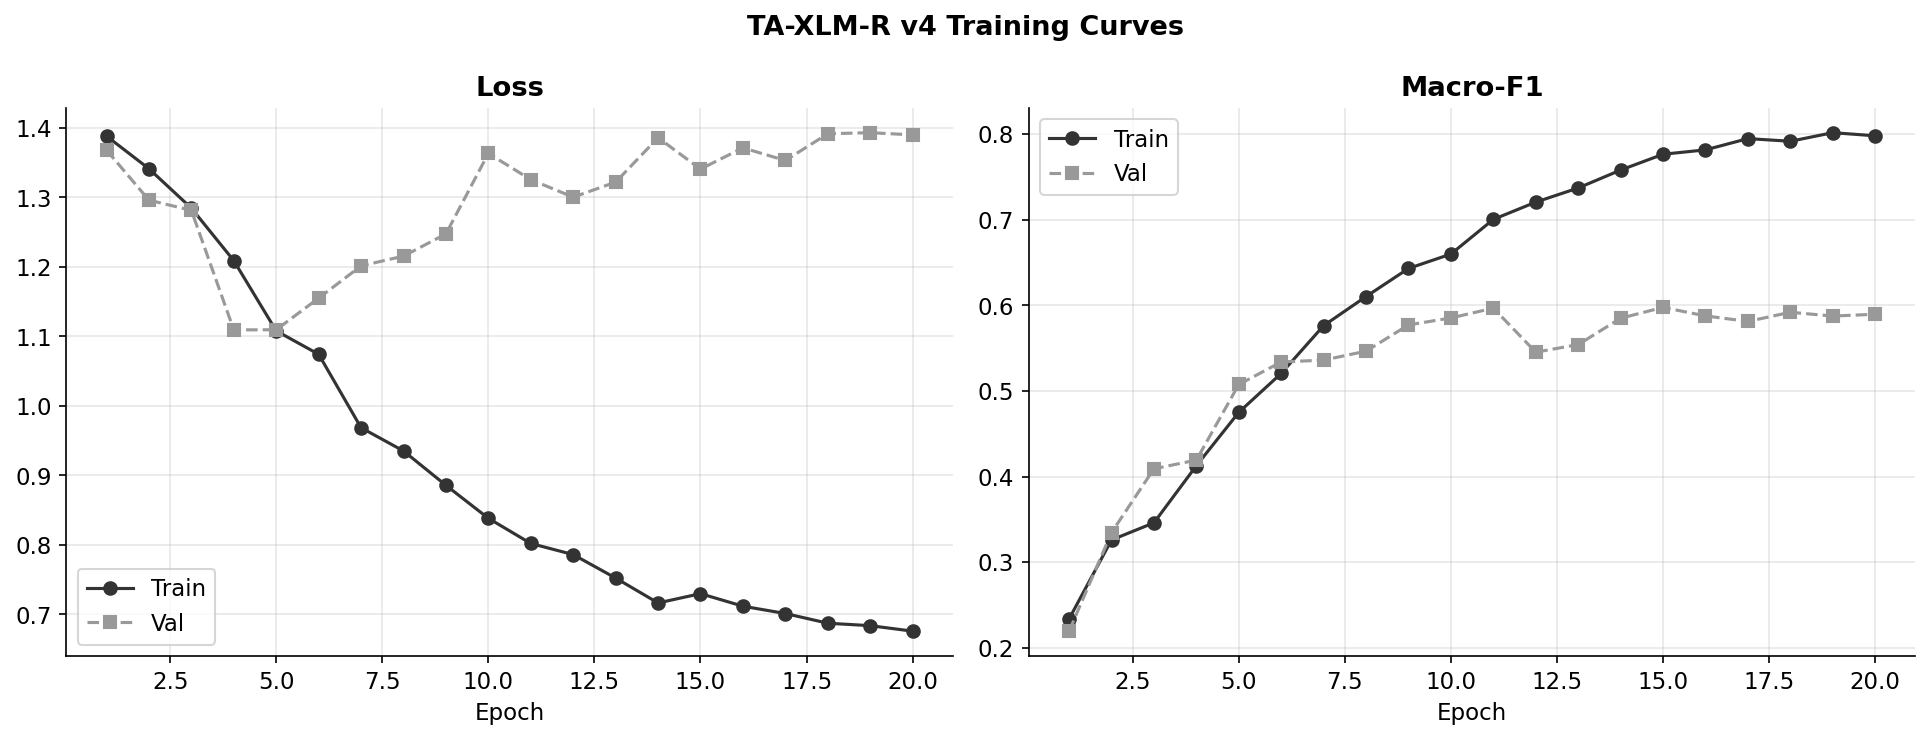

In [16]:
hist     = all_histories[best_seed_idx]
ep_range = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tr_key, vl_key), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_f1', 'val_f1')],
    ['Loss', 'Macro-F1']
):
    ax.plot(ep_range, hist[tr_key], '-o', color='0.2', label='Train', linewidth=1.5)
    ax.plot(ep_range, hist[vl_key], '--s', color='0.6', label='Val', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle(f'TA-XLM-R v4 Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_v4.png', bbox_inches='tight')
plt.show()

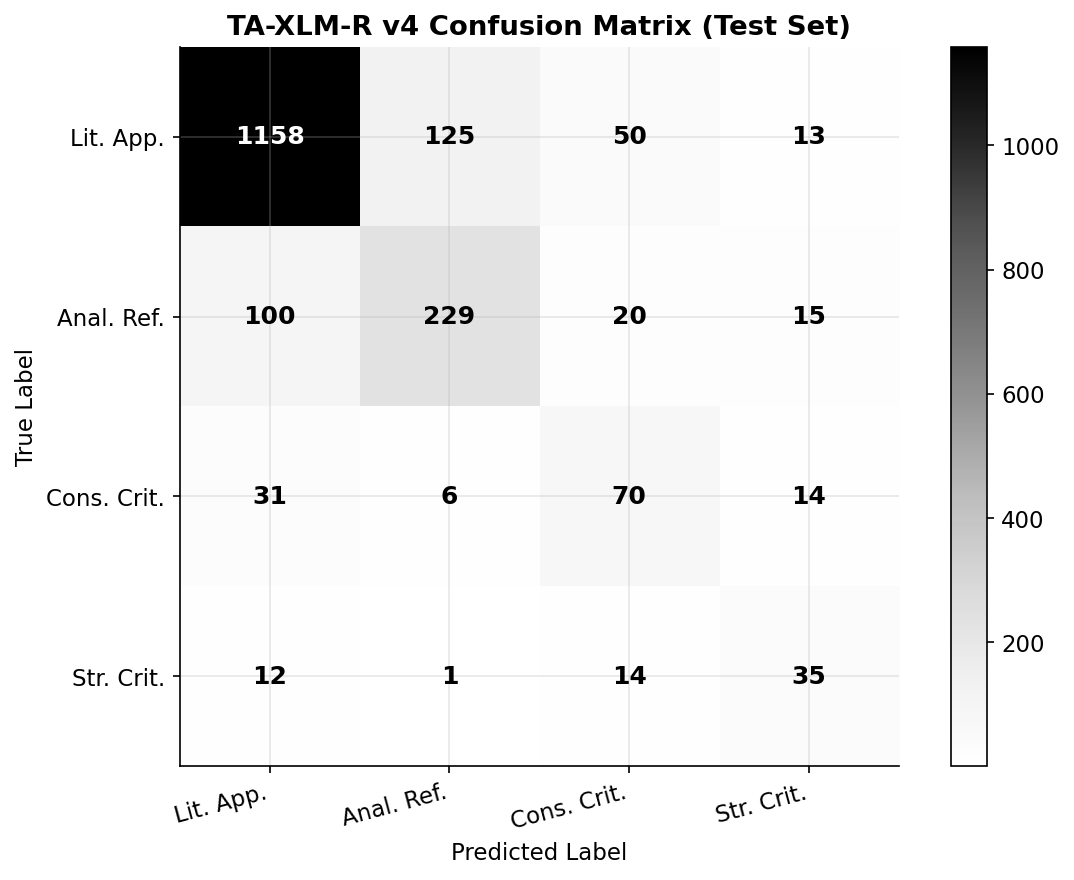

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Greys')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(SHORT_LBL, rotation=15, ha='right')
ax.set_yticklabels(SHORT_LBL)

thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_title('TA-XLM-R v4 Confusion Matrix (Test Set)', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_v4.png', bbox_inches='tight')
plt.show()

## 13. Save Artifacts

In [18]:
torch.save(best_model_state, 'ta_xlmr_v4_best.pt')

with open('char_vocab_v4.json', 'w', encoding='utf-8') as f:
    json.dump(CHAR_VOCAB, f, ensure_ascii=False, indent=2)

summary = {
    'model'       : 'TA-XLM-R v4',
    'improvements': [
        'Mean-pool + CLS fusion',
        'Char CNN (multi-scale 2,3,4-gram)',
        'Cross-modal attention fusion',
        'Differential LR (4 groups)',
        'Gradient accumulation (eff. batch=64)',
        'Mixup augmentation in embedding space',
        'SWA (Stochastic Weight Averaging)',
        'Expanded transliteration map (+20 entries)',
        'max_len=160, warmup=15%',
    ],
    'seeds'       : CFG['seeds'],
    'mean_metrics': {k: round(agg[k]['mean'], 4) for k in metrics_keys},
    'std_metrics' : {k: round(agg[k]['std'],  4) for k in metrics_keys},
    'target_met'  : bool(agg['macro_f1']['mean'] > 0.75),
}
with open('results_summary_v4.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Saved: ta_xlmr_v4_best.pt | char_vocab_v4.json | results_summary_v4.json')
print(f'\n  Final mean Macro-F1: {agg["macro_f1"]["mean"]:.4f} ± {agg["macro_f1"]["std"]:.4f}')
print(f'  Target >0.75 met: {"✅" if summary["target_met"] else "❌"}')

Saved: ta_xlmr_v4_best.pt | char_vocab_v4.json | results_summary_v4.json

  Final mean Macro-F1: 0.6242 ± 0.0059
  Target >0.75 met: ❌
